# Wine Quality — Machine Learning Regression Pipeline

## Objective

Build a complete **regression pipeline from scratch** using the Wine Quality dataset.

The purpose of this notebook is to understand the workflow:

**Dataset → Inspection → Cleaning → EDA → Features/Target → Train/Test Split → Model → Prediction → Evaluation → Experiments**

This is a learning experiment, so we will focus on **why each step exists**, not just on getting a prediction.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the Dataset

The dataset contains numerical physicochemical measurements of red wine and a `quality` score.

For this first experiment, we keep the problem simple:

- All input features are numerical.
- `quality` is the target.
- We will initially treat `quality` as a **regression target** because it is represented as a numerical value.


In [2]:
df = pd.read_csv("wine/winequality-red.csv", sep=";")


## 2. Initial Data Inspection

We start with a small set of standard checks:

- `head()` → inspect the first few rows.
- `shape` → understand the number of rows and columns.
- `info()` → inspect data types and non-null counts.
- `describe()` → inspect numerical distributions and ranges.

These checks help us understand the dataset before making modelling decisions.


In [3]:
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.shape

(1599, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 3. Duplicate Records

Before training a model, we should check whether exact duplicate rows exist.

Why?

Duplicate observations can give repeated information to the model and may affect the evaluation if the same observation appears more than once.

We first **inspect** duplicates before deciding how to handle them.


In [7]:
df.duplicated().sum()

np.int64(240)

In [8]:
df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
).head(20)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
142,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6
144,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6
131,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.0,5
132,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.0,5
1488,5.6,0.54,0.04,1.7,0.049,5.0,13.0,0.99420,3.72,0.58,11.4,5
1491,5.6,0.54,0.04,1.7,0.049,5.0,13.0,0.99420,3.72,0.58,11.4,5
996,5.6,0.66,0.00,2.2,0.087,3.0,11.0,0.99378,3.71,0.63,12.8,7
997,5.6,0.66,0.00,2.2,0.087,3.0,11.0,0.99378,3.71,0.63,12.8,7
829,5.9,0.61,0.08,2.1,0.071,16.0,24.0,0.99376,3.56,0.77,11.1,6
831,5.9,0.61,0.08,2.1,0.071,16.0,24.0,0.99376,3.56,0.77,11.1,6


In [9]:
df[df.duplicated()].head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5


## 4. Target Exploration

Our target variable is `quality`.

We examine:

- frequency of each quality value,
- descriptive statistics,
- relative proportions.

This tells us how the target is distributed and whether some values are much more common than others.


In [10]:
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

In [11]:
df["quality"].describe()

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

In [12]:
df["quality"].value_counts(normalize=True).sort_index()

quality
3    0.006254
4    0.033146
5    0.425891
6    0.398999
7    0.124453
8    0.011257
Name: proportion, dtype: float64

## 5. Data Cleaning

The dataset contains exact duplicate rows.

For this experiment, we remove exact duplicates:

```python
df = df.drop_duplicates()
```

After cleaning, we verify the resulting shape and confirm that no exact duplicates remain.


In [13]:
df = df.drop_duplicates()
df.shape
df.duplicated().sum()

np.int64(0)

## 6. Basic Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) means examining the data to understand its structure, distributions, relationships, and possible problems before modelling.

Here we start with the target distribution.

We are **not trying to perform every possible EDA operation**. We choose EDA based on the modelling problem and what the data tells us.


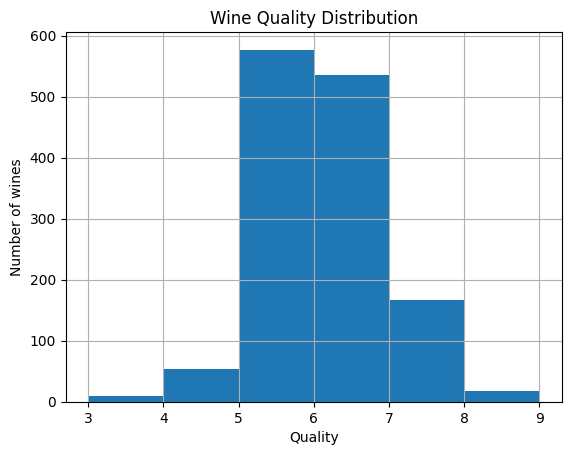

In [14]:
df["quality"].hist(bins=range(3, 10))
plt.xlabel("Quality")
plt.ylabel("Number of wines")
plt.title("Wine Quality Distribution")
plt.show()

## 7. Separate Features and Target

Machine learning models need us to distinguish between:

- **Features (X):** input variables used to make predictions.
- **Target (y):** the variable we want to predict.

Here:

- `X` = the 11 physicochemical measurements.
- `y` = `quality`.

The model will learn a relationship:

**X → quality**


In [15]:
X = df.drop("quality", axis=1)
y = df["quality"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1359, 11)
y shape: (1359,)


## 8. Train-Test Split

We divide the data into:

- **Training set:** used to learn the model parameters.
- **Test set:** kept aside to evaluate performance on unseen data.

We use 80% for training and 20% for testing.

`random_state=42` makes the split reproducible, so we get the same split each time we run the notebook.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

## 9. Baseline Model — Linear Regression

We start with a simple baseline rather than immediately choosing a complex algorithm.

### Linear Regression

Linear Regression assumes that the target can be approximated by a linear combination of the input features:

**ŷ = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ**

where:

- `ŷ` = predicted target
- `β₀` = intercept
- `β₁ ... βₙ` = learned coefficients
- `X₁ ... Xₙ` = input features

The model learns the coefficients from the training data.


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 10. Generate Predictions

After training, we use the trained model to predict `quality` for observations in the test set.

Important distinction:

**Training:** learn the model.

**Prediction:** use the learned model on new/unseen feature values.


In [ ]:
y_pred = model.predict(X_test)

## 11. Model Evaluation

We evaluate the predictions using four common regression metrics.

### Mean Absolute Error (MAE)

**Mean Absolute Error** measures the average absolute difference between actual and predicted values.

**Lower is better.**

### Mean Squared Error (MSE)

**Mean Squared Error** averages the squared prediction errors, giving larger errors more weight.

**Lower is better.**

### Root Mean Squared Error (RMSE)

**Root Mean Squared Error** is the square root of Mean Squared Error.

It is expressed in the same units as the target.

**Lower is better.**

### R-squared (R²)

**R-squared**, also called the coefficient of determination, measures how much of the variation in the target is explained by the model relative to a mean-prediction baseline.

For the usual interpretation, **higher is better**.

There is no universal cutoff that makes an R² value "good" or "bad"; we compare it with baselines, alternative models, and the requirements of the problem.


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.5041409053480702
MSE : 0.4310090050900949
RMSE: 0.6565127607976062
R²  : 0.39153604990582214


## 12. Actual vs Predicted Values

A simple comparison of actual and predicted values helps us understand individual predictions.

This is not a replacement for proper evaluation metrics, but it gives us a concrete view of model behaviour.


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,5,5.245601
1,6,5.809935
2,7,6.368405
3,5,5.158733
4,4,5.199286
5,7,6.776391
6,5,5.706717
7,5,4.844757
8,6,5.799955
9,5,5.739405


## 13. Feature Scaling Experiment

Some machine learning algorithms are sensitive to the scale of input features.

**StandardScaler** standardizes each feature approximately to:

- mean = 0
- standard deviation = 1

Important rule:

**Fit the scaler only on the training data, then transform both training and test data.**

```python
scaler.fit_transform(X_train)
scaler.transform(X_test)
```

We are experimenting with scaling here to understand its effect. Scaling is not automatically required for every algorithm.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Linear Regression on Scaled Features

We train the same Linear Regression model using the scaled features.

Because Linear Regression is being used here, we can compare the scaled and unscaled results directly.


In [ ]:
model_scaled = LinearRegression()

model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

### Compare Scaled vs Unscaled Results

If the evaluation metrics remain essentially unchanged, that tells us that scaling did not materially affect this particular Linear Regression experiment.

This does **not** mean scaling is unnecessary in machine learning generally. Its importance depends on the algorithm and the data.


In [ ]:
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print("Scaled Linear Regression")
print("MAE :", mae_scaled)
print("MSE :", mse_scaled)
print("RMSE:", rmse_scaled)
print("R²  :", r2_scaled)

Scaled Linear Regression
MAE : 0.5041409053480713
MSE : 0.4310090050900972
RMSE: 0.656512760797608
R²  : 0.3915360499058188


## 14. Training Performance

We now generate predictions on the **training set**.

This allows us to compare how the model performs on data it learned from versus data it did not see during training.


In [ ]:
y_train_pred = model.predict(X_train)

## 15. Training vs Test Performance

Comparing training and test performance helps us reason about **generalization**.

### Typical patterns

| Training | Test | Possible interpretation |
|---|---|---|
| Poor | Poor | Possible underfitting |
| Good | Similar to training | Good generalization |
| Very good | Much worse | Possible overfitting |

There is no universal numerical cutoff for the size of the gap. We look at the pattern, the problem, the metric, and supporting evidence.


In [ ]:
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Training R²:", train_r2)
print("Test R²    :", test_r2)

Training R²: 0.35199009757861066
Test R²    : 0.39153604990582214


## 16. Final Baseline Evaluation

We print the training and test values for:

- **Mean Absolute Error (MAE)**
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**
- **R-squared (R²)**

For this experiment, the training and test results are relatively close, so there is **no obvious large generalization gap** suggesting strong overfitting.

However, this comparison alone does not prove that Linear Regression is the best model or that it is not underfitting.

## Current Conclusion

We now have a complete first regression pipeline:

**Load → Inspect → Clean → Explore → Split → Train → Predict → Evaluate → Compare**

The next question is:

> **Can a more flexible model capture relationships that Linear Regression is missing?**

That leads naturally to the next experiment: **Polynomial Regression and model complexity.**


In [ ]:
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)

print("Training Mean Absolute Error (MAE) :", train_mae)
print("Training Mean Squared Error (MSE)  :", train_mse)
print("Training Root Mean Squared Error (RMSE):", train_rmse)
print("Training R²:", train_r2)

print("\nTest Mean Absolute Error (MAE) :", mae)
print("Test Mean Squared Error (MSE)  :", mse)
print("Test Root Mean Squared Error (RMSE):", rmse)
print("Test R²:", r2)

Training Mean Absolute Error (MAE) : 0.5106962445230673
Training Mean Squared Error (MSE)  : 0.4336734683793485
Training Root Mean Squared Error (RMSE): 0.6585388890409954
Training R²: 0.35199009757861066

Test Mean Absolute Error (MAE) : 0.5041409053480702
Test Mean Squared Error (MSE)  : 0.4310090050900949
Test Root Mean Squared Error (RMSE): 0.6565127607976062
Test R²: 0.39153604990582214


## Dataset Source

Wine Quality dataset from the UCI Machine Learning Repository.

**Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality.**

The dataset is used here for educational machine-learning practice. See the repository README for source and licensing information.
